# XGBoost 공정성 개선
직교화(Custom), CorrelationRemover, Threshold Tuning

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib fairlearn scipy -q

In [2]:
# 한글 폰트
import subprocess, matplotlib, matplotlib.font_manager as fm
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)
fm._load_fontmanager(try_read_cache=False)
font_prop = fm.FontProperties(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = font_prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료")

한글 폰트 설정 완료


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (confusion_matrix, average_precision_score, f1_score, precision_score, recall_score)

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

In [5]:
BASE_PATH  = '/content/drive/MyDrive/Colab Notebooks/리스크 공모전'
MODEL_PKL  = f'{BASE_PATH}/churn_model_xgb_final.pkl'
DATA_PKL   = f'{BASE_PATH}/Health_Insurance_final.pkl'

target = 'is_churn'
age_col    = 'age'
AGE_BINS   = [0, 19, 29, 39, 49, 59, 69, 100]
AGE_LABELS = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
CAT_COLS   = ['type_policy_dg', 'type_product', 'new_business',
              'distribution_channel', 'gender', 'C_C', 'kr_early_laps']
DROP_PCT   = 0.02   # 허용 PR-AUC 하락 비율 (실무 기준)
print("설정 완료")

설정 완료


### 공정성 및 성능 지표

In [6]:
# ===== 공정성 유틸 =====
from sklearn.linear_model import Ridge, LinearRegression

# 공정성 gap 지표
#  FPR Gap, TPR Gap, DP Gap, EO Gap (최종 best 선택 기준)
GAP_METRICS = ['FPR Gap', 'TPR Gap', 'DP Gap']
ALL_GAPS    = GAP_METRICS + ['EO Gap']           # sweep 계산용(EO=선택 기준)

def confusion_rates(y_true, y_pred):
    """(FPR, TPR, DP) 반환"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    sel = (tp + fp) / len(y_true) if len(y_true) else 0.0
    return fpr, tpr, sel

def group_rates(y_true, y_pred, groups, rate='fpr'):
    """그룹별 rate({'fpr'|'tpr'|'sel'}). 표본 10개 미만 / 단일클래스 그룹은 제외"""
    idx = {'fpr': 0, 'tpr': 1, 'sel': 2}[rate]
    groups = pd.Series(list(groups))
    rates = {}
    for g in sorted(groups.dropna().unique()):
        mask = (groups == g).values
        if mask.sum() < 10:
            continue
        yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
        if len(np.unique(yt)) < 2:
            continue
        rates[g] = round(confusion_rates(yt, yp)[idx], 4)
    return rates

def gap(rate_dict):
    """집단간 공정성 지표 격차 계산"""
    values = list(rate_dict.values())
    return round(max(values) - min(values), 4) if len(values) >= 2 else 0.0

def fairness_gaps(y_true, y_pred, groups):
    """FPR/TPR/DP/EO Gap 한 번에."""
    fpr = gap(group_rates(y_true, y_pred, groups, 'fpr'))
    tpr = gap(group_rates(y_true, y_pred, groups, 'tpr'))
    dp  = gap(group_rates(y_true, y_pred, groups, 'sel'))
    return {'FPR Gap': fpr, 'TPR Gap': tpr, 'DP Gap': dp, 'EO Gap': round(max(fpr, tpr), 4)}

def avg_gap(y_true, y_pred, sens_dict, metric):
    """민감변수 전체에 대한 metric gap 평균."""
    return round(np.mean([fairness_gaps(y_true, y_pred, g)[metric] for g in sens_dict.values()]), 4)

def perf_metrics(y_true, prob, pred):
    """성능 지표 dict."""
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {'PR-AUC': round(average_precision_score(y_true, prob), 4),
            'F1': round(f1_score(y_true, pred, zero_division=0), 4),
            'Precision': round(precision_score(y_true, pred, zero_division=0), 4),
            'Recall': round(recall_score(y_true, pred, zero_division=0), 4),
            'FPR': round(fp / (fp + tn), 4)}

### 전처리 방법 2가지

In [7]:
# ----- 직교화 & R² -----
def feature_r2(cols, source, basis):
    """각 수치형 피처를 basis(age, gender)로 적합했을 때 R²(민감정보 함량). 내림차순 Series."""
    r2 = {}
    for col in cols:
        x = source[col].values.astype(float)
        if np.isnan(x).any() or np.std(x) == 0:
            r2[col] = 0.0
            continue
        pred = LinearRegression().fit(basis, x).predict(basis)
        ss_res = np.sum((x - pred) ** 2)
        ss_tot = np.sum((x - x.mean()) ** 2)
        r2[col] = round(max(0.0, 1 - ss_res / ss_tot), 4)
    return pd.Series(r2).sort_values(ascending=False)

def orthogonalize(X_train, X_test, cols, basis_tr, basis_te, source_train=None, source_test=None):
    """cols의 각 컬럼을 basis에 대한 잔차로 대체. source 미지정 시 X 사용."""
    source_train = X_train if source_train is None else source_train
    source_test  = X_test  if source_test  is None else source_test

    # sweep에서 함수 반복 호출 시 직교화 누적으로 인한 버그 방지
    X_train, X_test = X_train.copy(), X_test.copy()
    for col in cols:
        # 회귀값
        reg = Ridge(alpha=1.0).fit(basis_tr, source_train[col].values.astype(float))
        # 잔차값
        X_train[col] = source_train[col].values.astype(float) - reg.predict(basis_tr)
        X_test[col]  = source_test[col].values.astype(float)  - reg.predict(basis_te)
    return X_train, X_test

def r2_grid(r2_series, max_points=12):
    """직교화 대상 집합이 바뀌는 R²경계값들로 τ grid 구성."""
    values = sorted({round(float(v), 4) for v in r2_series.values if v > 0})
    grid = [0.0] + values[:-1] if len(values) >= 2 else [0.0] # 0일 경우 전부 직교화, base는 이미 표에 존재
    if len(grid) > max_points:
        quantiles = np.quantile(grid, np.linspace(0, 1, max_points))
        grid = sorted({round(float(q), 4) for q in quantiles})
    return grid

# ----- CorrelationRemover (fairlearn) -----
# 표준 CR은 민감변수를 drop하나, baseline과의 feature 일관성 위해 민감변수와 범주형 변수 유지
# CorrelationRemover로 수치형 피처만 decorrlate하고, 민감피처와 수치형 피처 유지
def fit_correlation_remover(X, num_cols, sens_df, alpha):
    from fairlearn.preprocessing import CorrelationRemover
    Z = X[num_cols].astype(float).copy() # 비민감 수치형 피처
    for c in sens_df.columns:
        Z[c] = sens_df[c].values
    cr = CorrelationRemover(sensitive_feature_ids=list(sens_df.columns), alpha=alpha) # 상관구조 train 학습
    cr.fit(Z)
    return cr

def apply_correlation_remover(cr, X, num_cols, sens_df):
    Z = X[num_cols].astype(float).copy()
    for c in sens_df.columns:
        Z[c] = sens_df[c].values
    X = X.copy()
    X[num_cols] = cr.transform(Z)   # 비민감 피처 decorrelate, 민감 피처 drop
    return X

# ----- sweep & 선택 -----
def run_sweep(fit_fn, grid, threshold, y_val, sens_val, base_prauc_val, drop_limit):
    """val(2018)으로 pr_auc 허용 하락 계산하여 test 누수 방지 test 예측은 base에 대해 표로 비교하기 위함"""
    rows = []
    for value in grid:
        prob_val, prob_test, n_cols = fit_fn(value)
        pred_val  = (prob_val >= threshold).astype(int)
        prauc_val = average_precision_score(y_val, prob_val) #pr_auc 계산
        row = {'param': value, 'n_cols': n_cols, 'PR-AUC': round(prauc_val, 4),
               'F1': round(f1_score(y_val, pred_val, zero_division=0), 4),
               'drop': round(base_prauc_val - prauc_val, 4),
               'ok': (base_prauc_val - prauc_val) <= drop_limit, # 0.02 허용 하락에 대해 ok 여부 표시
               'prob': prob_test, 'pred': (prob_test >= threshold).astype(int)} # test 예측
        for metric in ALL_GAPS:
            row[metric] = avg_gap(y_val, pred_val, sens_val, metric)
        rows.append(row)
    return rows

def sweep_table(rows, param_name):
    cols = ['param', 'n_cols', 'PR-AUC', 'F1', 'drop', 'ok'] + ALL_GAPS
    return (pd.DataFrame([{c: r[c] for c in cols} for r in rows])
              .rename(columns={'param': param_name}).set_index(param_name))

def best_feasible(rows, metric):
    """성능 유지(ok)하는 대상 중 해당 공정성 지표 gap 최소화"""
    feasible = [r for r in rows if r['ok']]
    return min(feasible, key=lambda r: r[metric]) if feasible else None

def pick_best_variant(orth_rows, cr_rows, metric):
    """CR(표준 방법)과 orthogonalization 최적 후보를 선택해 gap 더 낮은 방법 변환"""
    candidates = []
    for method, rows in [('Orth', orth_rows), ('CR', cr_rows)]:
        best = best_feasible(rows, metric)
        if best:
            candidates.append((method, best))
    return min(candidates, key=lambda kv: kv[1][metric]) if candidates else (None, None)

### 그래프 및 표

In [8]:
# ----- 비교표 (test(2019) 기준 값) -----
def build_variants(base_prob, base_pred, orth_rows, cr_rows):
    """Baseline과 전처리 방법 2가지(Orth/CR) + 공정성 지표별 최적 후보"""
    variants = {'Base': {'prob': base_prob, 'pred': base_pred, 'param': '-'}}
    for method, rows in [('Orth', orth_rows), ('CR', cr_rows)]:
        for metric in GAP_METRICS:
            best = best_feasible(rows, metric)
            if best is None:
                continue
            variants[f'{method}[{metric}]'] = {'prob': best['prob'], 'pred': best['pred'], 'param': best['param']}
    return variants

def comparison_table(variants, y_test, sens_dict):
    rows = []
    for name, v in variants.items():
        row = {'Model': name, 'param': v['param'], **perf_metrics(y_test, v['prob'], v['pred'])} # 성능 지표
        for metric in GAP_METRICS:
            row[metric] = avg_gap(y_test, v['pred'], sens_dict, metric) # 공정성 지표
        rows.append(row)
    return pd.DataFrame(rows).set_index('Model')

def style_table(df, higher_better, lower_better, caption, base_row='Base'):
    """열별 최적값 초록, baseline 노랑 강조."""
    def color_best(s):
        if s.name in higher_better: # 높을수록 좋은 지표: 최대값 초록 표시
            best = s == s.max()
        elif s.name in lower_better: # 낮을수록 좋은 지표: 최소값 초록 표시
            best = s == s.min()
        else:
            return ['color:black'] * len(s)
        return ['background-color:#d4edda;font-weight:bold;color:black' if v else 'color:black' for v in best]
    # baseline
    def highlight_base(d):
        style = pd.DataFrame('', index=d.index, columns=d.columns)
        if base_row in d.index:
            style.loc[base_row] = 'background-color:#fff3cd;color:black'
        return style
    fmt = {c: '{:.4f}' for c in df.columns if str(df[c].dtype).startswith(('float', 'int'))}
    return df.style.apply(color_best).apply(highlight_base, axis=None).format(fmt).set_caption(caption)

# ----- 그래프 -----
def plot_pareto(sweep_df, base_prauc, drop_limit, model_name, fname):
    """(좌) 공정성 Avg Gap vs τ, (우) PR-AUC vs τ."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for metric in ALL_GAPS:
        axes[0].plot(sweep_df.index, sweep_df[metric], marker='o', label=metric)
    axes[0].set(xlabel='R² threshold τ', ylabel='Avg Gap (↓ 공정)', title=f'({model_name}) 공정성 Avg Gap')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)
    axes[1].plot(sweep_df.index, sweep_df['PR-AUC'], marker='o', color='#1f77b4')
    axes[1].axhline(base_prauc, ls='--', color='#ff7f0e', label=f'Base={base_prauc:.4f}')
    axes[1].axhline(base_prauc - drop_limit, ls=':', color='#d62728', label='허용 하한')
    axes[1].set(xlabel='R² threshold τ', ylabel='PR-AUC (↑ 성능)', title=f'({model_name}) 성능')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.savefig(fname, dpi=200, bbox_inches='tight'); plt.show()

def plot_group_bars(y_test, sens_dict, series, title, fname, rate='fpr', colors=None):
    """민감변수별 시각화"""
    rate_label = {'fpr': 'FPR (Predictive Equality)', 'tpr': 'TPR (Equal Opportunity)',
                  'sel': 'Selection Rate (Demographic Parity)'}[rate]
    colors = colors or ['#cfcfcf', '#9ecae1', '#a1d99b', '#f4a582']
    variables = list(sens_dict)
    ncol = 3
    nrow = int(np.ceil(len(variables) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 3.7 * nrow))
    axes = np.array(axes).reshape(-1)
    width = 0.8 / len(series)
    for ax, var in zip(axes, variables):
        groups = sens_dict[var]
        rate_by_series = []
        for label, preds in series:
            pred = preds[var]['pred'] if isinstance(preds, dict) else preds
            rate_by_series.append((label, group_rates(y_test, pred, groups, rate)))
        group_labels = sorted(set().union(*[set(r) for _, r in rate_by_series]))
        x = np.arange(len(group_labels))
        for i, (label, rates) in enumerate(rate_by_series):
            offset = (i - (len(series) - 1) / 2) * width
            ax.bar(x + offset, [rates.get(g, 0) for g in group_labels], width, label=label,
                   color=colors[i % len(colors)], edgecolor='#5a5a5a', linewidth=0.4)
        gap_text = ' / '.join(f"{label[:1]}{gap(rates):.2f}" for label, rates in rate_by_series)
        ax.set_title(f"{var}  Gap {gap_text}", fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(group_labels, rotation=30, ha='right', fontsize=7)
        ax.set_ylabel(rate_label, fontsize=7)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=6)
    for ax in axes[len(variables):]:
        ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

# ----- 민감변수별 요약표 (Base / 전처리 best / 후처리) -----
def per_variable_tables(y_test, sens_dict, rows, model_name, orth_tau=None):
    """민감변수별 표 1개씩(총 6개)"""
    lower_better  = ['DP Gap', 'FPR Gap', 'TPR Gap']
    higher_better = ['F1']
    tables = {}
    for var in sens_dict:
        groups = sens_dict[var]
        table_rows = []
        for label, preds in rows:
            if isinstance(preds, dict):
                pred = preds[var]['pred']
                name = label if preds[var].get('used', True) else f'{label} (revert)'
            else:
                pred, name = preds, label
            g = fairness_gaps(y_test, pred, groups) # 공정성 지표 (test)
            table_rows.append({'Model': name, 'DP Gap': g['DP Gap'], 'FPR Gap': g['FPR Gap'],
                               'TPR Gap': g['TPR Gap'],
                               'F1': round(f1_score(y_test, pred, zero_division=0), 4)})
        df = pd.DataFrame(table_rows).set_index('Model')
        caption = f"[{model_name}] {var} — Base / 전처리 / 후처리 (DP·FPR·TPR Gap·F1)"
        if orth_tau is not None:
            caption += f" | Orth τ={orth_tau}"
        tables[var] = df
        display(style_table(df, higher_better, lower_better, caption))
    return tables

### 후처리 방법 3가지

In [9]:
# ----- 후처리 방법 3가지 -----
# 방법 1
def tune_thresholds_fpr(prob_val, y_val, sens_val, prob_test, sens_test,
                        default_thr, rate='fpr', worsen_tol=0.01):
    """
    방법1) FPR 균등화(+악화 시 원복).
    val(2018)에서 그룹별 음성(y=0) 확률 분위수를 임계값으로 산출하여
    keep/revert(악화 시 공통 임계값 적용) 판단한 뒤, 확정된 임계값 test에 적용"""
    y_val = np.asarray(y_val)
    results = {}
    for var in sens_val:
        groups_val  = np.asarray(sens_val[var])
        groups_test = np.asarray(sens_test[var])
        if rate == 'fpr':
            neg = (y_val == 0)
            # 모든 그룹이 전체 FPR을 갖도록 target으로 함
            target = float((prob_val[neg] >= default_thr).mean()) if neg.sum() else 0.0
        else:
            target = float((prob_val >= default_thr).mean())
        group_thr = {}
        for g in pd.unique(groups_val):
            mask = (groups_val == g)
            if mask.sum() < 10:
                continue
            # quantile - 그룹별 임계값 산출 (e.g. fpr =0.3으로 맞추려면 그 그룹 음성들의 70번째 백분위수를 임계값으로 잡음)
            pool = prob_val[mask & (y_val == 0)] if rate == 'fpr' else prob_val[mask]
            group_thr[g] = float(np.quantile(pool, 1 - target)) if len(pool) else default_thr
        def apply_thr(prob, groups):
            out = (prob >= default_thr).astype(int)
            for g, t in group_thr.items():
                m = (groups == g)
                out[m] = (prob[m] >= t).astype(int)
            return out
        # 그룹별 튜닝이 gap을 키울 경우(소표본, 분포 특성 등 원인), 공통 임계값으로 revert
        gap_before = gap(group_rates(y_val, (prob_val >= default_thr).astype(int), pd.Series(groups_val), rate))
        gap_after  = gap(group_rates(y_val, apply_thr(prob_val, groups_val),        pd.Series(groups_val), rate))
        keep = gap_after < gap_before + worsen_tol
        pred_test = apply_thr(prob_test, groups_test) if keep else (prob_test >= default_thr).astype(int)
        results[var] = {'pred': pred_test, 'used': keep}
    return results

# 방법 2
def tune_thresholds_equalized_odds(estimator, X_val, y_val, sens_val, X_test, sens_test, fallback_pred):
    """
    방법2) fairlearn ThresholdOptimizer(equalized_odds), 실패(그룹 구성 문제 등) 시 방법 2 적용되지 않음"""
    from fairlearn.postprocessing import ThresholdOptimizer
    results = {}
    for var in sens_test:
        try:
            opt = ThresholdOptimizer(estimator=estimator, constraints='equalized_odds',
                                     objective='balanced_accuracy_score', prefit=True,
                                     predict_method='predict_proba')
            opt.fit(X_val, y_val, sensitive_features=np.asarray(sens_val[var])) # val로 그룹별 임계값 학습
            pred = opt.predict(X_test, sensitive_features=np.asarray(sens_test[var]), random_state=42) # test에 적용
            results[var] = {'pred': pred, 'used': True}
        except Exception as e:
            print(f"  [ThresholdOptimizer {var}] 실패: {e}")
            results[var] = {'pred': fallback_pred, 'used': False}
    return results

def tune_thresholds_f1max(prob_val, y_val, sens_val, prob_test, sens_test, default_thr):
    """
    방법3) 그룹별 val F1 최대 임계값을 test에 적용"""
    y_val = np.asarray(y_val)
    grid = np.linspace(0.02, 0.98, 49) # 49개 후보 임계값
    results = {}
    for var in sens_val:
        groups_val  = np.asarray(sens_val[var])
        groups_test = np.asarray(sens_test[var])
        group_thr = {}
        for g in pd.unique(groups_val):
            mask = (groups_val == g)
            if mask.sum() < 10:
                continue
            p, y = prob_val[mask], y_val[mask]
            if len(np.unique(y)) < 2:
                group_thr[g] = default_thr # 공통 임계값
                continue
            f1s = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in grid]
            group_thr[g] = float(grid[int(np.argmax(f1s))]) # 각 그룹에서 f1 최대인 t 선택
        pred = (prob_test >= default_thr).astype(int)
        for g, t in group_thr.items():
            m = (groups_test == g)
            pred[m] = (prob_test[m] >= t).astype(int)
        results[var] = {'pred': pred, 'used': True}
    return results

### 1. xgboost baseline 및 데이터 로드

In [10]:
with open(MODEL_PKL, 'rb') as f:
    pkg = pickle.load(f)
base_model    = pkg['model']
feature_names = pkg['feature_names']
threshold     = float(pkg['threshold'])

xgb_params = base_model.get_params()
xgb_params.pop('early_stopping_rounds', None)
xgb_params.pop('callbacks', None)

xgb_params['device'] = 'cuda'

if getattr(base_model, 'best_iteration', None) is not None:
    xgb_params['n_estimators'] = base_model.best_iteration + 1
else:
    xgb_params['n_estimators'] = base_model.get_booster().num_boosted_rounds()

print(f"feature_names ({len(feature_names)}개), threshold={threshold:.4f}")
print(feature_names)

feature_names (22개), threshold=0.5024
['premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business', 'log_cost_claims_year', 'distribution_channel', 'age', 'gender', 'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T', 'missing_geo_cxt', 'high_loss', 'relative_poverty', 'kr_premium_shock', 'kr_economic_stress', 'kr_early_laps', 'kr_medical_desert']


In [11]:
with open(DATA_PKL, 'rb') as f:
    data = pickle.load(f)
for col in CAT_COLS:
    data[col] = data[col].astype(str).astype('category')

train = data[data['period'].isin([2017, 2018])]
test  = data[data['period'] == 2019]
y_train, y_test = train[target], test[target]
print(f"train={train.shape}, test={test.shape}")

train=(150999, 43), test=(75667, 43)


In [12]:
# baseline
prob_base = base_model.predict_proba(test[feature_names])[:, 1]
pred_base = (prob_base >= threshold).astype(int)
print("=== XGB Base ===")
for k, v in perf_metrics(y_test, prob_base, pred_base).items():
    print(f"  {k}: {v}")

=== XGB Base ===
  PR-AUC: 0.399
  F1: 0.4128
  Precision: 0.3381
  Recall: 0.5301
  FPR: 0.1994


### 2. 직교화 기저 생성 및 R²계산

In [13]:
# 직교화 기저: age_group 더미 + gender + age×gender + age(연속) + age²
train_ag = pd.cut(train[age_col], bins=AGE_BINS, labels=AGE_LABELS)
test_ag  = pd.cut(test[age_col],  bins=AGE_BINS, labels=AGE_LABELS)

age_encoder  = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
age_dummy_tr = age_encoder.fit_transform(train_ag.values.reshape(-1, 1))
age_dummy_te = age_encoder.transform(test_ag.values.reshape(-1, 1))

gender_ref = train['gender'].astype(str).unique()[1]
gender_tr = (train['gender'].astype(str) == gender_ref).astype(float).values.reshape(-1, 1)
gender_te = (test['gender'].astype(str)  == gender_ref).astype(float).values.reshape(-1, 1)

interact_tr = age_dummy_tr * gender_tr           # age×gender 교호작용(곱)
interact_te = age_dummy_te * gender_te

age_tr = train[age_col].values.astype(float).reshape(-1, 1)
age_te = test[age_col].values.astype(float).reshape(-1, 1)
age_mean, age_std = age_tr.mean(), age_tr.std()
age_z_tr = (age_tr - age_mean) / age_std
age_z_te = (age_te - age_mean) / age_std

basis_tr = np.hstack([age_dummy_tr, gender_tr, interact_tr, age_z_tr, age_z_tr ** 2])
basis_te = np.hstack([age_dummy_te, gender_te, interact_te, age_z_te, age_z_te ** 2])
print(f"기저 행렬 train={basis_tr.shape}")

기저 행렬 train=(150999, 15)


In [14]:
x_train_base = train[feature_names]   # category dtype 유지
x_test_base  = test[feature_names]

# 기저를 구성하는 데 쓰인 age, gender는 민감변수면서, 직교화에 넣으면 잔차가 0이 되어 무의미하므로 직교화 대상에서 제외
num_feats = [c for c in feature_names if c not in CAT_COLS and c != 'age']
r2_series = feature_r2(num_feats, x_train_base, basis_tr)
print("XGBoost Feature별 기저와의 R²:")
print(r2_series.to_string())

XGBoost Feature별 기저와의 R²:
kr_premium_shock        0.9194
seniority_policy        0.2405
premium                 0.1998
log_cost_claims_year    0.0603
C_IE_T                  0.0246
C_H_num                 0.0245
C_GI                    0.0132
high_loss               0.0108
IICIMUN_capped          0.0101
relative_poverty        0.0080
missing_geo_cxt         0.0056
kr_medical_desert       0.0050
kr_economic_stress      0.0026
IICIPROV                0.0018


### 3. 민감변수 그룹

In [15]:
# 민감변수 그룹: age_group / gender / age_gender / c_h / c_gi / c_ie_t
AG_BINS, AG_LABELS = [0, 25, 40, 60, 100], ['청년', '중년', '장년', '고령']
age_gender_tr = pd.cut(train[age_col], AG_BINS, labels=AG_LABELS).astype(str) + '_' + train['gender'].astype(str)
age_gender_te = pd.cut(test[age_col],  AG_BINS, labels=AG_LABELS).astype(str) + '_' + test['gender'].astype(str)

# C_GI(소득 수준), C_IE_T(교육 수준): 4구간+Unknown
# C_H_num(인구 규모 분류): 금액코드→라벨
SENS_CONFIG = {
    'C_GI':    {'bins': [-2, 0, 25, 50, 75, 100], 'labels': ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4']},
    'C_IE_T':  {'bins': [-2, 0, 25, 50, 75, 100], 'labels': ['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4']},
    'C_H_num': {'map': {500: 'H1', 5500: 'H2', 17500: 'H3', 37500: 'H4', 75000: 'H5', 150000: 'H6', -1: 'Unknown'}},
}
for col, cfg in SENS_CONFIG.items():
    for df in [train, test]:
        if 'bins' in cfg:
            grp = pd.cut(df[col], bins=cfg['bins'], labels=cfg['labels'])
            df[f'{col}_grp'] = grp.astype(str).replace('nan', np.nan)
        else:
            df[f'{col}_grp'] = df[col].map(cfg['map']).fillna('Unknown')

def build_sensitive(df, age_group, age_gender):
    return {'age_group': age_group, 'gender': df['gender'].astype(str), 'age_gender': age_gender,
            'c_h': df['C_H_num_grp'], 'c_gi': df['C_GI_grp'], 'c_ie_t': df['C_IE_T_grp']}

sensitive_test  = build_sensitive(test,  test_ag,  age_gender_te)
sensitive_train = build_sensitive(train, train_ag, age_gender_tr)
for k, v in sensitive_test.items():
    print(f"  {k:12s}: {sorted(pd.Series(v).dropna().unique())}")

  age_group   : ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
  gender      : ['F', 'M']
  age_gender  : ['고령_F', '고령_M', '장년_F', '장년_M', '중년_F', '중년_M', '청년_F', '청년_M']
  c_h         : ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'Unknown']
  c_gi        : ['GI_1', 'GI_2', 'GI_3', 'GI_4', 'Unknown']
  c_ie_t      : ['C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4', 'Unknown']


In [16]:
# validation = 2018 (후처리 threshold tuning 및 orth best 재적합용)
#baseline / ortogonalization 모델은 2017+2018로 학습 → 2018은 학습에 포함된(in-sample) 검증
val_mask = (train['period'] == 2018).values
y_val = y_train[val_mask]
sensitive_val = {k: v[val_mask] for k, v in sensitive_train.items()}
print(f"validation(2018) n={int(val_mask.sum())}")

validation(2018) n=73474


### baseline 민감변수별 성능 및 공정성 지표

In [17]:
def sens_report(var, y_true, prob, pred, sens_dict):
    g = pd.Series(list(sens_dict[var]))
    rows = {}
    for k in sorted(g.dropna().unique()):
        m = (g == k).values
        yt = np.asarray(y_true)[m]
        if m.sum() < 10 or len(np.unique(yt)) < 2:
            continue
        yp = np.asarray(pred)[m]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows[k] = {'n': int(m.sum()), 'selection_rate': (tp + fp) / len(yt),
                   'tpr': tp / (tp + fn), 'tnr': tn / (tn + fp),
                   'fpr': fp / (fp + tn), 'fnr': fn / (fn + tp)}
    df = pd.DataFrame(rows).T
    print(f"===== [{var}] 그룹별 공정성 세부 =====")
    print("----- 전체 성능 -----")
    for kk, vv in perf_metrics(y_true, prob, pred).items():
        print(f"  {kk}: {vv}")
    print("----- 집단 간 최대 격차 (max-min) -----")
    for c in ['selection_rate', 'tpr', 'tnr', 'fpr', 'fnr']:
        print(f"  {c:15s}: {round(df[c].max() - df[c].min(), 4)}")
    return df

- 성별

In [18]:
sens_report('gender', y_test, prob_base, pred_base, sensitive_test)

===== [gender] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.399
  F1: 0.4128
  Precision: 0.3381
  Recall: 0.5301
  FPR: 0.1994
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.0288
  tpr            : 0.006
  tnr            : 0.0348
  fpr            : 0.0348
  fnr            : 0.006


,n,selection_rate,tpr,tnr,fpr,fnr
F,41143.0,0.239555,0.532828,0.816429,0.183571,0.467172
M,34524.0,0.268364,0.526786,0.781669,0.218331,0.473214


- 연령대

In [19]:
sens_report('age_group', y_test, prob_base, pred_base, sensitive_test)

===== [age_group] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.399
  F1: 0.4128
  Precision: 0.3381
  Recall: 0.5301
  FPR: 0.1994
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.3334
  tpr            : 0.3075
  tnr            : 0.2961
  fpr            : 0.2961
  fnr            : 0.3075


,n,selection_rate,tpr,tnr,fpr,fnr
10s,13000.0,0.384385,0.603424,0.677451,0.322549,0.396576
20s,6650.0,0.417143,0.643213,0.643525,0.356475,0.356787
30s,12126.0,0.351971,0.581238,0.707723,0.292277,0.418762
40s,12078.0,0.267346,0.506121,0.783605,0.216395,0.493879
50s,10004.0,0.184126,0.446188,0.856335,0.143665,0.553812
60s,10094.0,0.083713,0.335673,0.939604,0.060396,0.664327
70s+,11715.0,0.099531,0.377717,0.929413,0.070587,0.622283


- 성별_연령대

In [20]:
sens_report('age_gender',   y_test, prob_base, pred_base, sensitive_test)

===== [age_gender] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.399
  F1: 0.4128
  Precision: 0.3381
  Recall: 0.5301
  FPR: 0.1994
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.3111
  tpr            : 0.2745
  tnr            : 0.2784
  fpr            : 0.2784
  fnr            : 0.2745


,n,selection_rate,tpr,tnr,fpr,fnr
고령_F,11922.0,0.084969,0.340040,0.938232,0.061768,0.659960
고령_M,8988.0,0.097686,0.375581,0.931718,0.068282,0.624419
장년_F,11730.0,0.201364,0.483240,0.849396,0.150604,0.516760
장년_M,9890.0,0.249039,0.479895,0.792786,0.207214,0.520105
중년_F,9175.0,0.359128,0.598671,0.705776,0.294224,0.401329
중년_M,7289.0,0.358623,0.573919,0.694108,0.305892,0.426081
청년_F,8316.0,0.383117,0.614555,0.683331,0.316669,0.385445
청년_M,8357.0,0.396075,0.601453,0.659866,0.340134,0.398547


- c_h (소득수준)

In [21]:
sens_report('c_h', y_test, prob_base, pred_base, sensitive_test)

===== [c_h] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.399
  F1: 0.4128
  Precision: 0.3381
  Recall: 0.5301
  FPR: 0.1994
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.2658
  tpr            : 0.3379
  tnr            : 0.2344
  fpr            : 0.2344
  fnr            : 0.3379


,n,selection_rate,tpr,tnr,fpr,fnr
H1,843.0,0.094899,0.267857,0.931601,0.068399,0.732143
H2,7662.0,0.251762,0.528653,0.809927,0.190073,0.471347
H3,9621.0,0.262239,0.514423,0.798684,0.201316,0.485577
H4,6207.0,0.360722,0.605729,0.697211,0.302789,0.394271
H5,6430.0,0.325350,0.593168,0.741735,0.258265,0.406832
H6,42594.0,0.231605,0.512500,0.815167,0.184833,0.487500
Unknown,2310.0,0.170130,0.515385,0.873659,0.126341,0.484615


- c_gi (인구 규모)

In [22]:
sens_report('c_gi',   y_test, prob_base, pred_base, sensitive_test)

===== [c_gi] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.399
  F1: 0.4128
  Precision: 0.3381
  Recall: 0.5301
  FPR: 0.1994
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.2245
  tpr            : 0.1812
  tnr            : 0.1927
  fpr            : 0.1927
  fnr            : 0.1812


,n,selection_rate,tpr,tnr,fpr,fnr
GI_1,1859.0,0.281872,0.554707,0.791269,0.208731,0.445293
GI_2,6361.0,0.377771,0.617468,0.694717,0.305283,0.382532
GI_3,10875.0,0.372598,0.645769,0.699907,0.300093,0.354231
GI_4,53519.0,0.218128,0.480692,0.825936,0.174064,0.519308
Unknown,3053.0,0.153292,0.464589,0.887407,0.112593,0.535411


- c_ie_t (교육수준)

In [23]:
sens_report('c_ie_t', y_test, prob_base, pred_base, sensitive_test)

===== [c_ie_t] 그룹별 공정성 세부 =====
----- 전체 성능 -----
  PR-AUC: 0.399
  F1: 0.4128
  Precision: 0.3381
  Recall: 0.5301
  FPR: 0.1994
----- 집단 간 최대 격차 (max-min) -----
  selection_rate : 0.1926
  tpr            : 0.1778
  tnr            : 0.1668
  fpr            : 0.1668
  fnr            : 0.1778


,n,selection_rate,tpr,tnr,fpr,fnr
C_IE_T_1,18088.0,0.345920,0.597358,0.720618,0.279382,0.402642
C_IE_T_2,18133.0,0.278553,0.557668,0.780263,0.219737,0.442332
C_IE_T_3,18164.0,0.235851,0.504381,0.809512,0.190488,0.495619
C_IE_T_4,18229.0,0.167919,0.419596,0.867987,0.132013,0.580404
Unknown,3053.0,0.153292,0.464589,0.887407,0.112593,0.535411


### 방법론 — 직교화(Custom) & CorrelationRemover(표준)

**보호속성과 basis**

- 직접적 보호속성은 age, gender / 지역 및 소득 변수(C_H_num, C_GI, C_IE_T)는 자체가 보호속성이 아니라 age, gender를 간접적으로 담을 수 있는 대리변수(proxy)
- 각 수치형 피처에서 basis(보호속성 기저)로 설명되는 간접차별 성분을 제거하고자, basis는 age, gender로 구성 -> age_group 더미 + gender + age×gender + age(연속형) + age(연속형)^2

1. **CorrelationRemover (표준, fairlearn)** — 비민감 피처를 민감 피처로 선형회귀한 잔차로 대체(`alpha`로 강도 조절)하며, 전 수치형 피처에 적용
2. **Custom 직교화** — 비선형 basis로 잔차화하되, 민감정보 함량(R^2)이 임계 τ를 넘는 피처만 선택적 직교화

- 하이퍼파라미터(τ, alpha, best 방법)와 후처리 임계값은 모두 val(2018)으로 선택
- 최종 결과는 test(2019)로 하므로 데이터 누수 X
- PR-AUC 하락 ≤ Baseline val(2018)의 PR-AUC×0.02
- 단 baseline과 ortho 모델이 2017+2018로 train되어 2018이 학습에 포함되므로 val은 완전 독립 holdout은 아닌 게 방법론의 한계임

---
**지표 설명**
- alpha : correlationremover는 수치형 피처(14개)에 대해 decorrelate하는 강도 (0~1, 0이 피처 원본 = baseline과 동일)
- tau : baseline의 validation set(2018)의 PR-AUC = `0.7621` 기준으로 2% 하락(실무 기준)만 허용하는 값 (tau = 0 은 R^2 > 0 인 피처 전부 직교화 -> 최대 직교화)
- n_cols :  tau 값에 따른 직교화 변수 개수 (correlationremover은 전 수치형 피처 모두 적용하므로 항상 14개)
- F1 : validation set 기준 f1 score
- ok : 허용 하락 범위 안에 들어오는지 여부(False/True)
- FPR/TPR/DP/EO Gap : 민감변수 6개 Gap (max-min) 의 평균

In [24]:
# CorrelationRemover (val 기준 alpha 선택)
prob_base_val  = base_model.predict_proba(train[feature_names])[:, 1][val_mask]
base_prauc_val = average_precision_score(y_val, prob_base_val)
drop_limit     = base_prauc_val * DROP_PCT
print(f"Base PR-AUC(val)={base_prauc_val:.4f}, 허용 하락={drop_limit:.4f} ({DROP_PCT:.0%})")

gender_code_tr = (train['gender'].astype(str) == gender_ref).astype(float).values
gender_code_te = (test['gender'].astype(str)  == gender_ref).astype(float).values
sens_df_tr = pd.DataFrame({'age': train[age_col].astype(float).values, 'gender': gender_code_tr})
sens_df_te = pd.DataFrame({'age': test[age_col].astype(float).values,  'gender': gender_code_te})

def fit_cr_xgb(alpha):
    cr = fit_correlation_remover(x_train_base, num_feats, sens_df_tr, alpha)
    X_tr = apply_correlation_remover(cr, x_train_base, num_feats, sens_df_tr)
    X_te = apply_correlation_remover(cr, x_test_base,  num_feats, sens_df_te)
    model = XGBClassifier(**xgb_params)
    model.fit(X_tr, y_train, verbose=False)
    prob_val  = model.predict_proba(X_tr)[:, 1][val_mask] # 선택
    prob_test = model.predict_proba(X_te)[:, 1] # 평가
    return prob_val, prob_test, len(num_feats)

cr_rows = run_sweep(fit_cr_xgb, np.round(np.linspace(0, 1, 6), 2), threshold, y_val, sensitive_val, base_prauc_val, drop_limit)
print("CorrelationRemover alpha sweep:")
display(sweep_table(cr_rows, 'alpha'))

Base PR-AUC(val)=0.7679, 허용 하락=0.0154 (2%)
CorrelationRemover alpha sweep:


,n_cols,PR-AUC,F1,drop,ok,FPR Gap,TPR Gap,DP Gap,EO Gap
alpha,,,,,,,,,
0.0,14,0.7624,0.6469,0.0055,True,0.1961,0.2117,0.2665,0.2152
0.2,14,0.7526,0.6356,0.0154,True,0.2150,0.2096,0.2662,0.2223
0.4,14,0.7480,0.6319,0.0199,False,0.2204,0.2101,0.2653,0.2263
0.6,14,0.7496,0.6345,0.0183,False,0.2170,0.2070,0.2653,0.2216
0.8,14,0.7438,0.6292,0.0241,False,0.2206,0.2075,0.2670,0.2244
1.0,14,0.7428,0.6315,0.0252,False,0.2203,0.2069,0.2648,0.2243


Base PR-AUC(val)=0.7679, 허용 하락=0.0154 (2%)


,n_cols,PR-AUC,F1,drop,ok,FPR Gap,TPR Gap,DP Gap,EO Gap
τ,,,,,,,,,
0.0000,14,0.7555,0.6405,0.0124,True,0.2054,0.2103,0.2633,0.2155
0.0019,13,0.7563,0.6419,0.0116,True,0.2002,0.2078,0.2602,0.2117
0.0035,12,0.7558,0.6435,0.0122,True,0.2025,0.2057,0.2606,0.2126
0.0053,11,0.7629,0.6461,0.0050,True,0.2056,0.2092,0.2669,0.2200
0.0073,10,0.7655,0.6489,0.0024,True,0.1991,0.2060,0.2629,0.2109
0.0099,9,0.7666,0.6507,0.0013,True,0.1983,0.2035,0.2643,0.2098
0.0110,7,0.7657,0.6502,0.0022,True,0.1972,0.2044,0.2629,0.2103
0.0163,6,0.7672,0.6509,0.0007,True,0.1961,0.2041,0.2622,0.2087
0.0245,5,0.7656,0.6499,0.0024,True,0.1976,0.2066,0.2676,0.2104


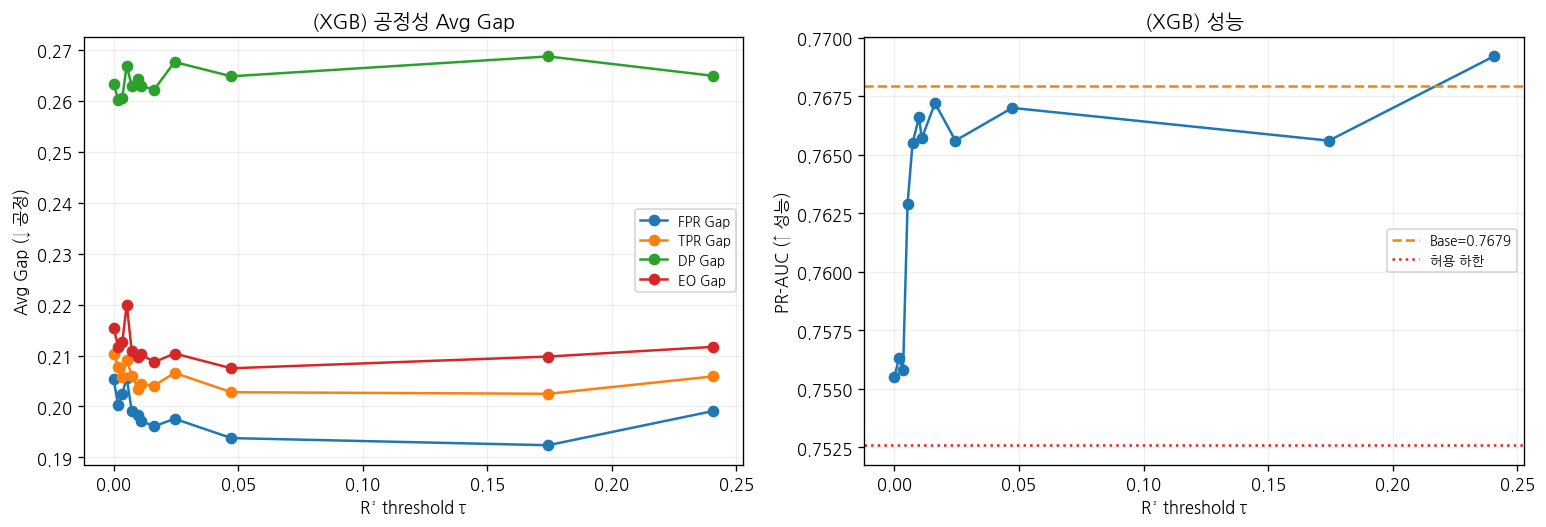

In [26]:
# Custom 직교화 (val 기준 tau 선택)
prob_base_val = base_model.predict_proba(train[feature_names])[:, 1][val_mask]
base_prauc_val = average_precision_score(y_val, prob_base_val)
drop_limit = base_prauc_val * DROP_PCT
print(f"Base PR-AUC(val)={base_prauc_val:.4f}, 허용 하락={drop_limit:.4f} ({DROP_PCT:.0%})")

def fit_orth_xgb(tau):
    cols = r2_series[r2_series > tau].index.tolist()
    X_tr, X_te = orthogonalize(x_train_base, x_test_base, cols, basis_tr, basis_te)
    model = XGBClassifier(**xgb_params)
    model.fit(X_tr, y_train, verbose=False)
    prob_val  = model.predict_proba(X_tr)[:, 1][val_mask]
    prob_test = model.predict_proba(X_te)[:, 1]
    return prob_val, prob_test, len(cols)

orth_rows = run_sweep(fit_orth_xgb, r2_grid(r2_series), threshold, y_val, sensitive_val, base_prauc_val, drop_limit)
sweep = sweep_table(orth_rows, 'τ')   # gap·PR-AUC는 val 기준(선택용)
display(sweep)
plot_pareto(sweep, base_prauc_val, drop_limit, 'XGB', 'pareto_xgb.png')

## 전처리 및 공정성 지표 조합별 최적 선택

In [27]:
variants = build_variants(prob_base, pred_base, orth_rows, cr_rows)
cmp = comparison_table(variants, y_test, sensitive_test)
higher = ['PR-AUC', 'F1', 'Precision', 'Recall'] # 높을수록 good
lower  = ['FPR', 'FPR Gap', 'TPR Gap', 'DP Gap'] # 낮을수록 good
display(style_table(cmp, higher, lower,
                    "XGBoost - Orth, CR × 성능 및 공정성 지표별 (gap 작을수록 공정, 성능 유지)"))

,param,PR-AUC,F1,Precision,Recall,FPR,FPR Gap,TPR Gap,DP Gap
Model,,,,,,,,,
Base,-,0.3990,0.4128,0.3381,0.5301,0.1994,0.2005,0.2142,0.2260
Orth[FPR Gap],0.174400,0.3971,0.4073,0.3540,0.4795,0.1681,0.1585,0.1971,0.1859
Orth[TPR Gap],0.174400,0.3971,0.4073,0.3540,0.4795,0.1681,0.1585,0.1971,0.1859
Orth[DP Gap],0.001900,0.3967,0.4084,0.3636,0.4657,0.1566,0.1602,0.2045,0.1896
CR[FPR Gap],0.000000,0.4005,0.4091,0.3345,0.5267,0.2013,0.1992,0.1971,0.2225
CR[TPR Gap],0.200000,0.3948,0.4070,0.3314,0.5273,0.2044,0.2032,0.2276,0.2290
CR[DP Gap],0.200000,0.3948,0.4070,0.3314,0.5273,0.2044,0.2032,0.2276,0.2290


### Best 모델 — 민감변수별 그룹 지표 (Baseline vs Best)
- val 기준으로 생성된 표에서 EO Gap이 최소인 tau 선택 (동률 후보 중 보호속성과 proxy를 가장 많이 제거하는 tau인 가장 작은 tau 선택하도록 설계)

XGB Best = Orth (τ=0.0473) | 선택기준 val: EO Gap=0.2075, F1=0.6509


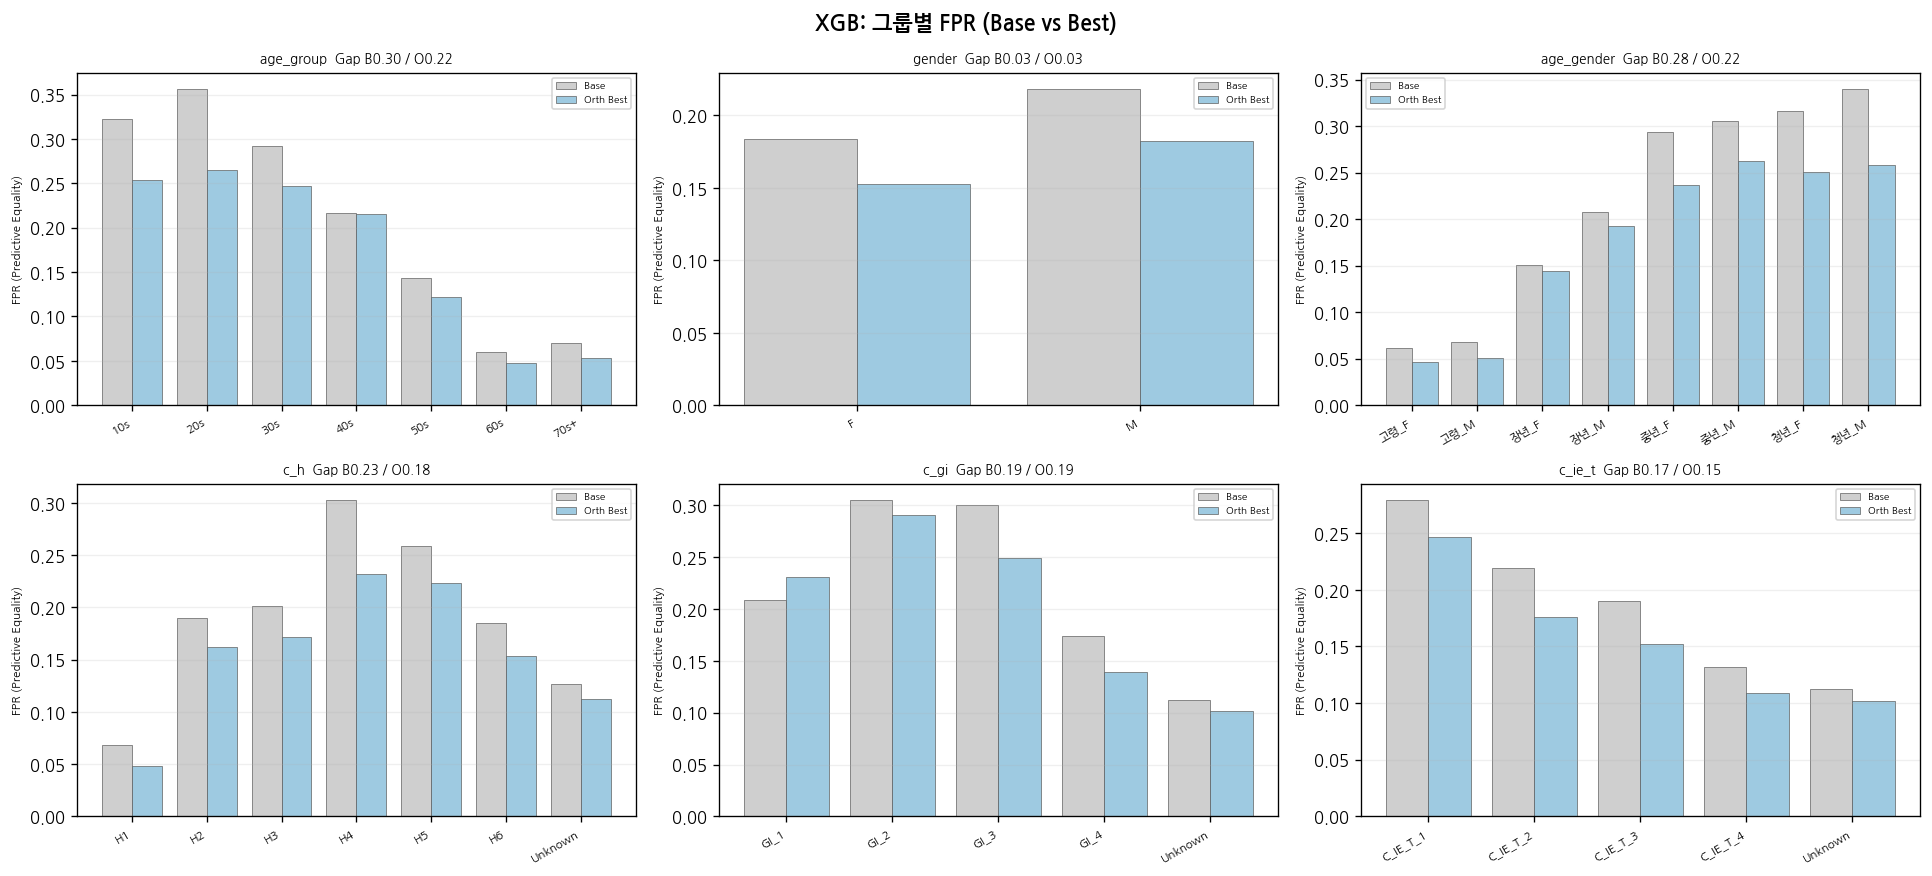

In [28]:
best_method, best = pick_best_variant(orth_rows, cr_rows, 'EO Gap')
# 아래 EO Gap·F1은 '선택 기준'인 val(2018) 값 — 최종 test 수치는 custom 직교화 표 참조
print(f"XGB Best = {best_method} (τ={best['param']}) | 선택기준 val: EO Gap={best['EO Gap']:.4f}, F1={best['F1']:.4f}")
plot_group_bars(y_test, sensitive_test,
                [('Base', pred_base), (f'{best_method} Best', best['pred'])],
                "XGB: 민감변수 그룹별 FPR (Base vs Best)", "group_xgb.png", rate='fpr')

### Threshold Tuning (후처리 3방법)

직교화(전처리) best 모델 위에 그룹별 임계값을 조정하는 후처리. 민감변수별 표 6개 생성.
- **방법1) FPR 균등화 (gap 악화 시 revert)**: val(2018)에서 전체 FPR을 목표로 각 그룹 음성(y=0) 확률 분위수를 임계값으로. gap이 원래보다 커지면 (0.01↑) 그 변수는 공통 임계값으로 revert.
- **방법2) ThresholdOptimizer (fairlearn)**: `equalized_odds` 제약으로 val 그룹별 최적 threshold 학습 → test.
- **방법3) val-F1max**: 각 그룹에서 val F1을 최대화하는 임계값 → test.
- 후처리는 그룹별 threshold를 적용하므로 F1이 민감변수, 방법마다 달라짐.

In [29]:
# 직교화 best 재적합
best_orth = best_feasible(orth_rows, 'EO Gap')
orth_cols = r2_series[r2_series > best_orth['param']].index.tolist()
X_tr_orth, X_te_orth = orthogonalize(x_train_base, x_test_base, orth_cols, basis_tr, basis_te)
orth_model = XGBClassifier(**xgb_params)
orth_model.fit(X_tr_orth, y_train, verbose=False)
prob_test_orth = orth_model.predict_proba(X_te_orth)[:, 1]
prob_val_orth  = orth_model.predict_proba(X_tr_orth)[:, 1][val_mask]
pred_orth  = (prob_test_orth >= threshold).astype(int)
X_val_orth = X_tr_orth[val_mask]

In [30]:
# 후처리 방법 3가지
res_fpr = tune_thresholds_fpr(prob_val_orth, y_val, sensitive_val, prob_test_orth,
                              sensitive_test, threshold, rate='fpr')
res_eo  = tune_thresholds_equalized_odds(orth_model, X_val_orth, y_val, sensitive_val,
                                         X_te_orth, sensitive_test, fallback_pred=pred_orth)
res_f1  = tune_thresholds_f1max(prob_val_orth, y_val, sensitive_val, prob_test_orth,
                                sensitive_test, threshold)

per_variable_tables(y_test, sensitive_test, [
    ('Base', pred_base),
    ('전처리 best (Orth)', pred_orth),
    ('+FPR균등화', res_fpr),
    ('+ThresholdOpt(EO)', res_eo),
    ('+F1max', res_f1),
], 'XGB', orth_tau=best_orth['param'])

,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.3334,0.2961,0.3075,0.4128
전처리 best (Orth),0.2556,0.2170,0.2532,0.4043
+FPR균등화,0.0496,0.0688,0.2110,0.3885
+ThresholdOpt(EO),0.0517,0.0649,0.1490,0.3789
+F1max,0.1336,0.1067,0.1607,0.3846


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.0288,0.0347,0.0060,0.4128
전처리 best (Orth),0.0260,0.0294,0.0048,0.4043
+FPR균등화,0.0065,0.0012,0.0384,0.4043
+ThresholdOpt(EO),0.0079,0.0015,0.0446,0.4047
+F1max,0.0334,0.0342,0.0268,0.3741


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.3111,0.2783,0.2746,0.4128
전처리 best (Orth),0.2502,0.2160,0.2559,0.4043
+FPR균등화,0.0450,0.0583,0.2360,0.3876
+ThresholdOpt(EO),0.0458,0.0638,0.1812,0.3787
+F1max,0.1373,0.1114,0.1512,0.3811


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.2658,0.2344,0.3378,0.4128
전처리 best (Orth),0.2119,0.1840,0.2826,0.4043
+FPR균등화,0.0957,0.1211,0.2595,0.4011
+ThresholdOpt(EO),0.0847,0.1125,0.1582,0.3934
+F1max,0.1096,0.0789,0.2094,0.3885


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.2245,0.1927,0.1812,0.4128
전처리 best (Orth),0.2155,0.1890,0.1746,0.4043
+FPR균등화,0.1299,0.1171,0.1645,0.4001
+ThresholdOpt(EO),0.1079,0.1158,0.0973,0.3906
+F1max,0.1347,0.1025,0.1322,0.3846


,DP Gap,FPR Gap,TPR Gap,F1
Model,,,,
Base,0.1926,0.1668,0.1778,0.4128
전처리 best (Orth),0.1714,0.1456,0.1957,0.4043
+FPR균등화,0.0496,0.0522,0.1774,0.3976
+ThresholdOpt(EO),0.0455,0.0560,0.0858,0.3872
+F1max,0.0972,0.0711,0.0864,0.3828


{'age_group':                    DP Gap  FPR Gap  TPR Gap      F1
 Model                                              
 Base               0.3334   0.2961   0.3075  0.4128
 전처리 best (Orth)    0.2556   0.2170   0.2532  0.4043
 +FPR균등화            0.0496   0.0688   0.2110  0.3885
 +ThresholdOpt(EO)  0.0517   0.0649   0.1490  0.3789
 +F1max             0.1336   0.1067   0.1607  0.3846,
 'gender':                    DP Gap  FPR Gap  TPR Gap      F1
 Model                                              
 Base               0.0288   0.0347   0.0060  0.4128
 전처리 best (Orth)    0.0260   0.0294   0.0048  0.4043
 +FPR균등화            0.0065   0.0012   0.0384  0.4043
 +ThresholdOpt(EO)  0.0079   0.0015   0.0446  0.4047
 +F1max             0.0334   0.0342   0.0268  0.3741,
 'age_gender':                    DP Gap  FPR Gap  TPR Gap      F1
 Model                                              
 Base               0.3111   0.2783   0.2746  0.4128
 전처리 best (Orth)    0.2502   0.2160   0.2559  0.4043
 +FPR균등

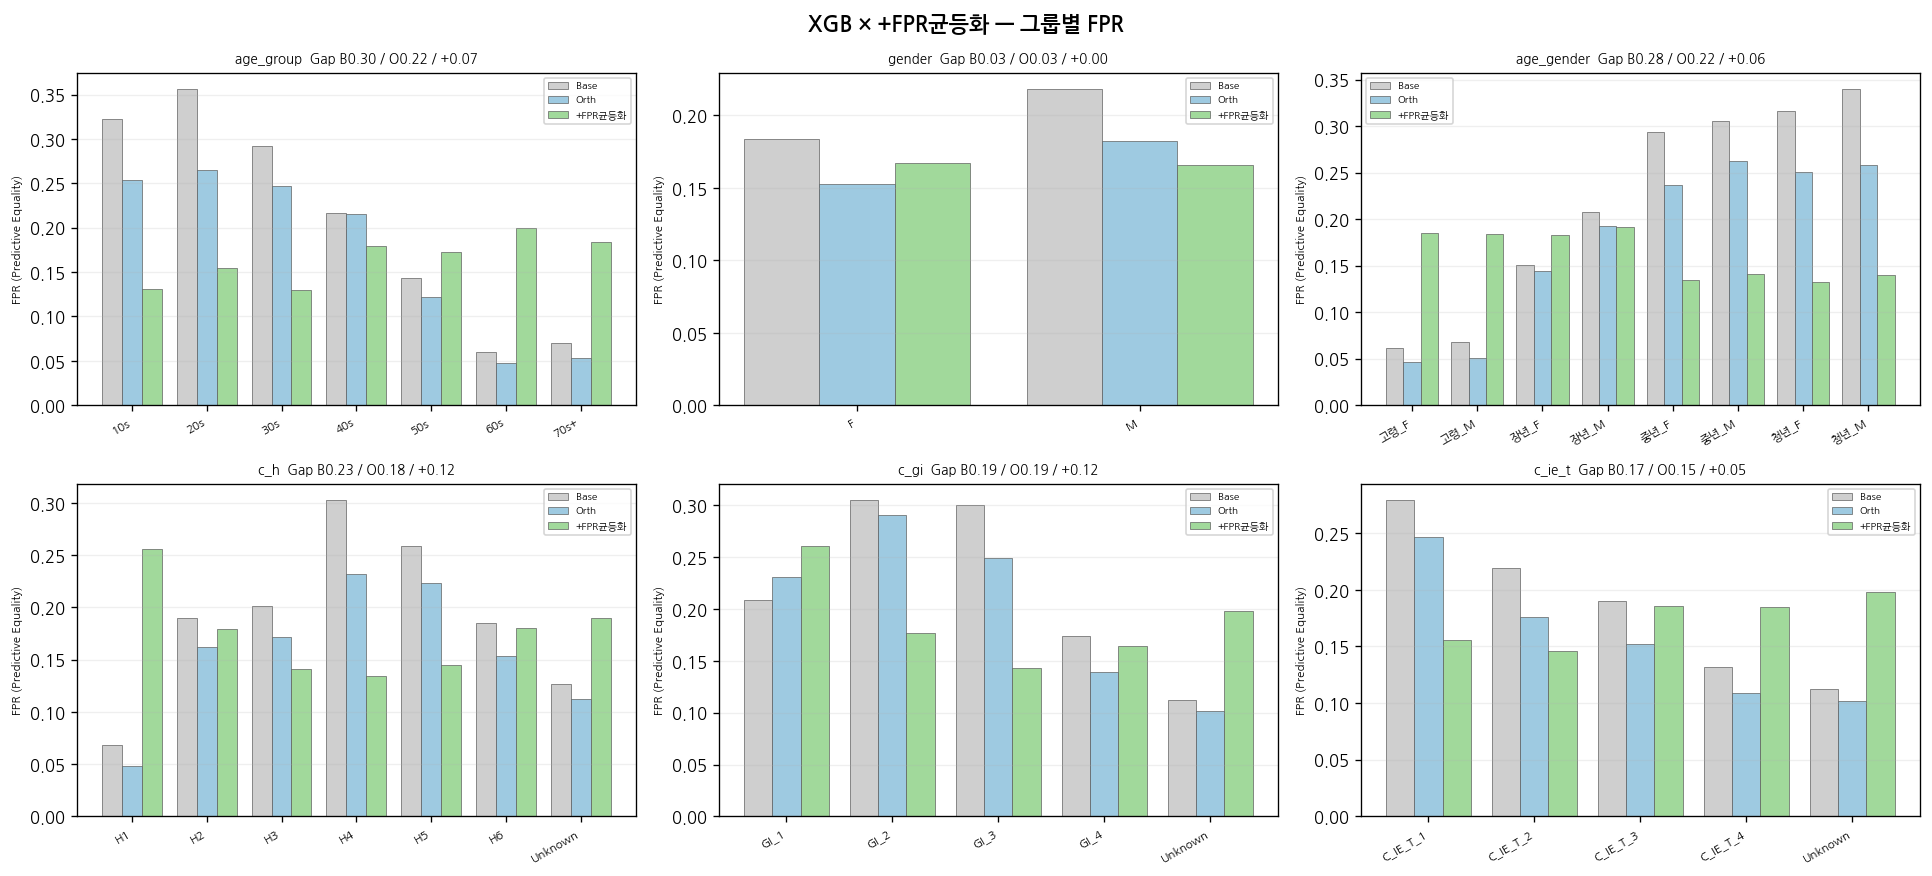

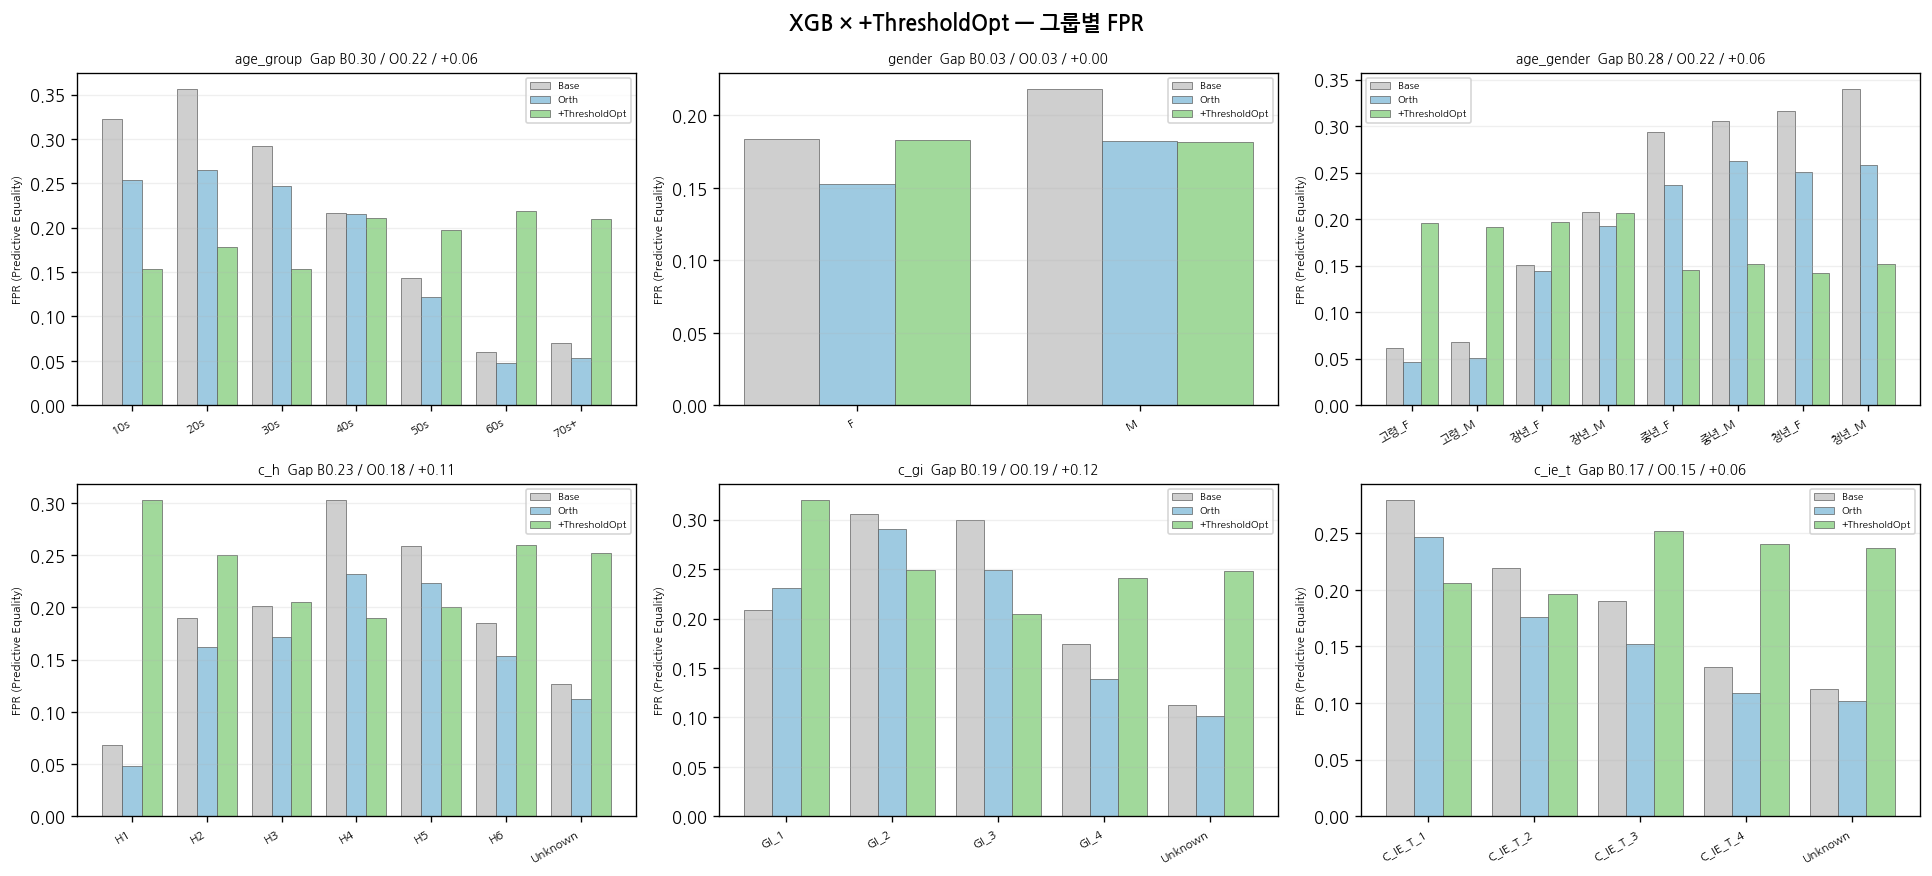

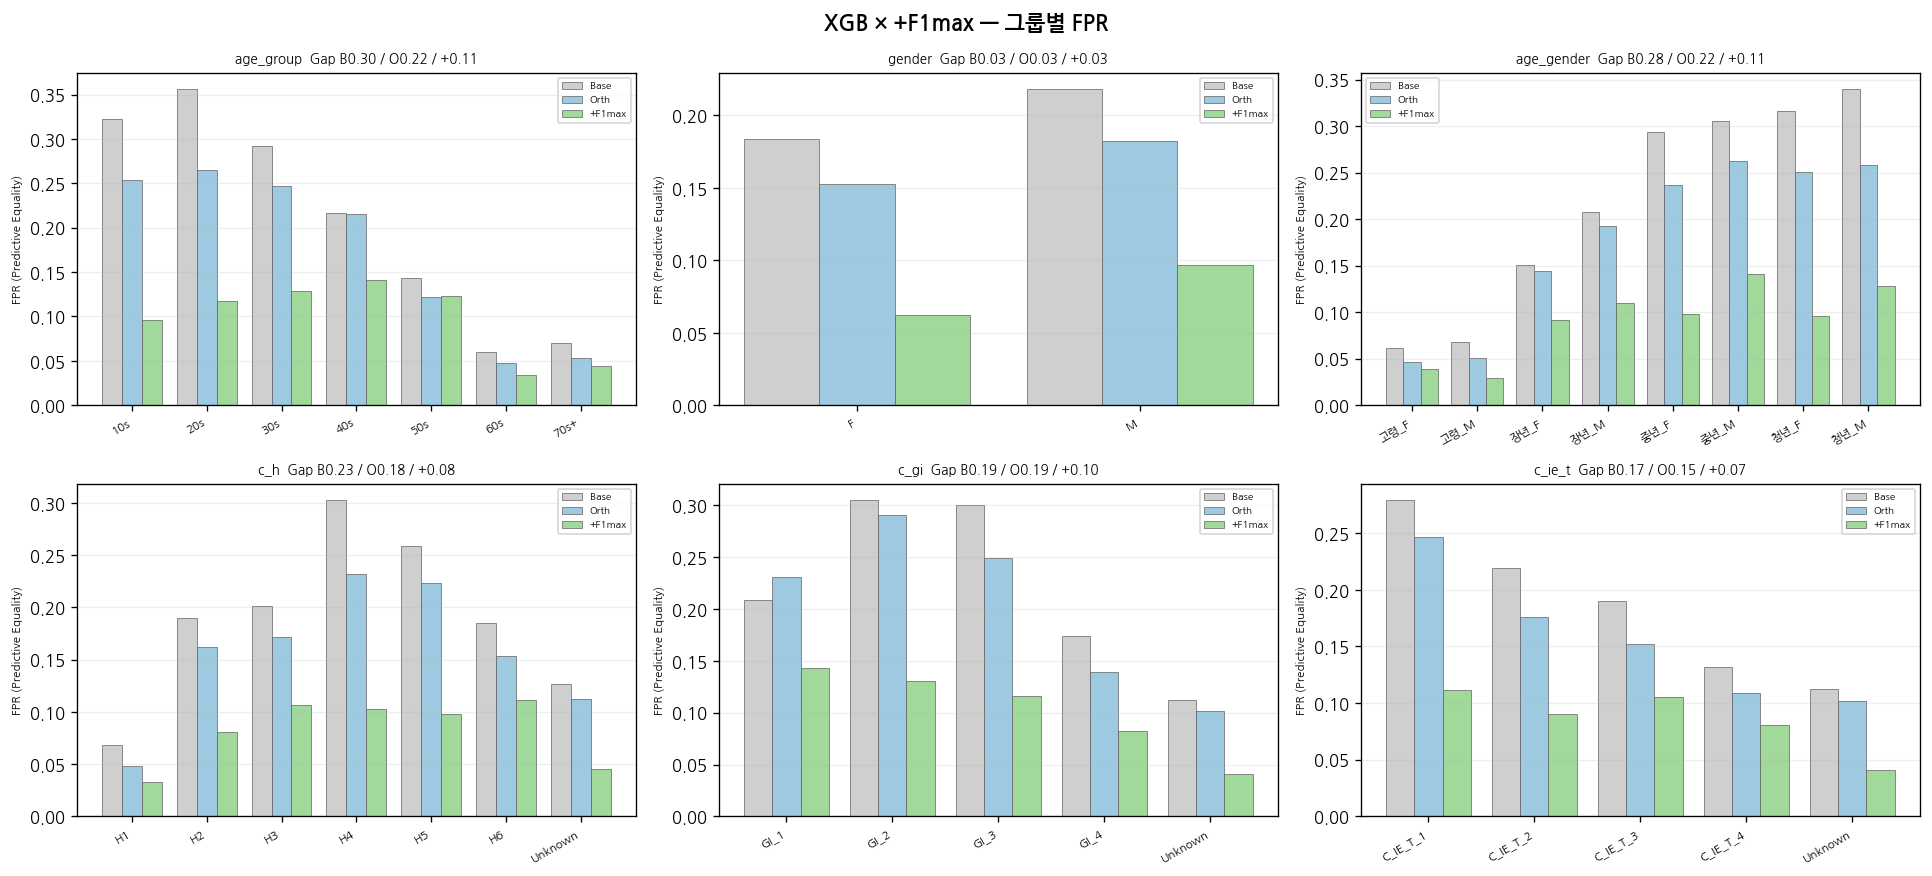

In [31]:
# 시각화
for res, method, fname in [(res_fpr, '+FPR균등화', 'tt_xgb_fpr.png'),
                           (res_eo, '+ThresholdOpt', 'tt_xgb_to.png'),
                           (res_f1, '+F1max', 'tt_xgb_f1.png')]:
    plot_group_bars(y_test, sensitive_test,
                    [('Base', pred_base), ('Orth', pred_orth), (method, res)],
                    f"XGB × {method} — 그룹별 FPR", fname, rate='fpr')